# Cenário 5: Erros Correlacionados AR(1) - Simulação MRLS

## Objetivo
Estudar o comportamento do MQO no MRLS quando os erros apresentam dependência serial do tipo AR(1).

## Especificação do cenário
- Resposta gerada por um modelo linear simples.
- Erros com correlação positiva entre observações consecutivas.
- Foco em estimação, cobertura de intervalos, testes e diagnóstico dos resíduos.

## Estrutura
Seguimos a mesma sequência do notebook de referência: definir parâmetros, gerar dados, ajustar o modelo, repetir a simulação, resumir os resultados e produzir gráficos.

---

## Algoritmo de Simulação

In [5]:
# 1. Importar bibliotecas
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson
from tqdm import tqdm

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

### Passo 1: Definir parâmetros do modelo
Usamos um intercepto pequeno, inclinação positiva e autocorrelação AR(1) moderada para deixar os efeitos visíveis nas tabelas e nos gráficos.

In [6]:
# 2. Configuração de parâmetros
BETA0_TRUE = 1.0
BETA1_TRUE = 2.0
SIGMA = 1.0
RHO = 0.7
SAMPLE_SIZES = [30, 100]
NUM_REPLICATIONS = 1000
ALPHA = 0.05
SEED = 20260506
X_LOW = -2.0
X_HIGH = 2.0
OUTPUT_DIR = 'cenario5_resultados'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Parâmetros do Cenário 5: erros correlacionados AR(1)')
print(f'  beta0 = {BETA0_TRUE}')
print(f'  beta1 = {BETA1_TRUE}')
print(f'  sigma = {SIGMA}')
print(f'  rho = {RHO}')
print(f'  n = {SAMPLE_SIZES}')
print(f'  B = {NUM_REPLICATIONS}')
print(f'  X ~ Uniforme({X_LOW}, {X_HIGH})')

Parâmetros do Cenário 5: erros correlacionados AR(1)
  beta0 = 1.0
  beta1 = 2.0
  sigma = 1.0
  rho = 0.7
  n = [30, 100]
  B = 1000
  X ~ Uniforme(-2.0, 2.0)


#### Funções utilitárias
Geramos X, construímos os erros AR(1), montamos Y, ajustamos o modelo e resumimos as repetições.

In [ ]:
# 3. Funções utilitárias
def generate_X(n):
    """Passo 2: Gera X uniformemente distribuído ou carrega CSV existente.
    Se existir 'X_n{n}.csv' no diretório atual, carrega-o; caso contrário, gera e salva."""
    filename = f"X_n{n}.csv"
    # Se o arquivo existir, tentar carregar e retornar os valores
    if os.path.exists(filename):
        try:
            df = pd.read_csv(filename, header=None)
            return df.iloc[:, 0].to_numpy()
        except Exception as e:
            print(f"Aviso: falha ao ler {filename}: {e}. Gerando novo X.")

def generate_ar1_errors(n, sigma, rho, rng):
    sigma_u = sigma * np.sqrt(1 - rho ** 2)
    innovations = rng.normal(0.0, sigma_u, size=n)
    eps = np.zeros(n, dtype=float)
    eps[0] = rng.normal(0.0, sigma)
    for i in range(1, n):
        eps[i] = rho * eps[i - 1] + innovations[i]
    return eps

def generate_Y_scenario5(X, beta0, beta1, sigma, rho, rng):
    epsilon = generate_ar1_errors(len(X), sigma, rho, rng)
    Y = beta0 + beta1 * X + epsilon
    return Y, epsilon

def fit_ols_model(X, Y, alpha):
    X_with_const = sm.add_constant(X, has_constant='add')
    model = sm.OLS(Y, X_with_const).fit()
    ci = model.conf_int(alpha=alpha)
    return {
        'beta0_hat': float(model.params[0]),
        'beta1_hat': float(model.params[1]),
        'se_beta0': float(model.bse[0]),
        'se_beta1': float(model.bse[1]),
        'ci_beta0_low': float(ci[0, 0]),
        'ci_beta0_high': float(ci[0, 1]),
        'ci_beta1_low': float(ci[1, 0]),
        'ci_beta1_high': float(ci[1, 1]),
        'pvalue_beta1': float(model.pvalues[1]),
        'resid': np.array(model.resid),
        'fitted': np.array(model.fittedvalues),
        'r_squared': float(model.rsquared),
        'dw_stat': float(durbin_watson(model.resid)),
    }

def summarize_estimator(estimates, true_value):
    mean_est = np.mean(estimates)
    bias = mean_est - true_value
    variance = np.var(estimates, ddof=1)
    mse = np.mean((estimates - true_value) ** 2)
    return {'mean': mean_est, 'bias': bias, 'variance': variance, 'mse': mse, 'std_dev': np.sqrt(variance)}

def compute_coverage(ci_low, ci_high, true_value):
    return float(np.mean((ci_low <= true_value) & (true_value <= ci_high)))

def compute_rejection_rate(pvalues, alpha):
    return float(np.mean(pvalues < alpha))

def run_replications(X, beta1_generation, rng):
    rows = []
    dw_values = []
    diagnostic_sample = None
    for rep in tqdm(range(NUM_REPLICATIONS), desc=f'beta1={beta1_generation}'):
        Y, _ = generate_Y_scenario5(X, BETA0_TRUE, beta1_generation, SIGMA, RHO, rng)
        fit = fit_ols_model(X, Y, ALPHA)
        rows.append({
            'beta0_hat': fit['beta0_hat'],
            'beta1_hat': fit['beta1_hat'],
            'se_beta0': fit['se_beta0'],
            'se_beta1': fit['se_beta1'],
            'ci_beta0_low': fit['ci_beta0_low'],
            'ci_beta0_high': fit['ci_beta0_high'],
            'ci_beta1_low': fit['ci_beta1_low'],
            'ci_beta1_high': fit['ci_beta1_high'],
            'pvalue_beta1': fit['pvalue_beta1'],
            'r_squared': fit['r_squared'],
            'dw_stat': fit['dw_stat'],
        })
        dw_values.append(fit['dw_stat'])
        if diagnostic_sample is None:
            diagnostic_sample = {'residuals': np.array(fit['resid']), 'fitted': np.array(fit['fitted']), 'dw_stat': fit['dw_stat']}
    return pd.DataFrame(rows), np.array(dw_values), diagnostic_sample

### Passos 2-4: Gerar X uma única vez e preparar a simulação
A mesma amostra de X é reutilizada em todas as repetições para que o efeito estudado fique concentrado nos erros correlacionados.

In [8]:
# 4. Simulação principal
rng = np.random.default_rng(SEED)
results = {}
results_null = {}

for n in SAMPLE_SIZES:
    X = generate_X(n, rng, X_LOW, X_HIGH)

    print('\n' + '='*60)
    print(f'Simulação para n = {n} | cenário alternativo')
    print('='*60)

    alt_frame, dw_alt, diag_alt = run_replications(X, BETA1_TRUE, rng)
    null_frame, dw_null, _ = run_replications(X, 0.0, rng)

    results[n] = {
        'X': X,
        'alt_frame': alt_frame,
        'null_frame': null_frame,
        'beta0_hats': alt_frame['beta0_hat'].to_numpy(),
        'beta1_hats': alt_frame['beta1_hat'].to_numpy(),
        'se_beta0': alt_frame['se_beta0'].to_numpy(),
        'se_beta1': alt_frame['se_beta1'].to_numpy(),
        'ci_beta0_low': alt_frame['ci_beta0_low'].to_numpy(),
        'ci_beta0_high': alt_frame['ci_beta0_high'].to_numpy(),
        'ci_beta1_low': alt_frame['ci_beta1_low'].to_numpy(),
        'ci_beta1_high': alt_frame['ci_beta1_high'].to_numpy(),
        'pvalue_beta1': alt_frame['pvalue_beta1'].to_numpy(),
        'dw_alt': dw_alt,
        'dw_null': dw_null,
        'residuals_diagnostic': diag_alt['residuals'],
        'fitted_diagnostic': diag_alt['fitted'],
        'dw_diagnostic': diag_alt['dw_stat'],
        'r_squared': alt_frame['r_squared'].to_numpy(),
    }

    print(f'✓ Simulação concluída para n = {n}')

    results_null[n] = {
        'pvalue_beta1': null_frame['pvalue_beta1'].to_numpy(),
        'dw_stat': dw_null,
    }

    print(f'✓ Simulação nula concluída para n = {n}')

print('\n' + '='*60)
print('Todas as simulações foram concluídas com sucesso!')
print('='*60)


Simulação para n = 30 | cenário alternativo


beta1=0.0: 100%|██████████| 1000/1000 [00:01<00:00, 689.13it/s]


✓ Simulação concluída para n = 30
✓ Simulação nula concluída para n = 30

Simulação para n = 100 | cenário alternativo


beta1=0.0: 100%|██████████| 1000/1000 [00:01<00:00, 571.95it/s]

✓ Simulação concluída para n = 100
✓ Simulação nula concluída para n = 100

Todas as simulações foram concluídas com sucesso!


## Etapas do Trabalho

### Etapa 1: Estimação
Análise das propriedades dos estimadores: média, viés, variância e EQM.

In [9]:
# Cálculo de estatísticas de estimação
estimation_summary = []

for n in SAMPLE_SIZES:
    summary_beta0 = summarize_estimator(results[n]['beta0_hats'], BETA0_TRUE)
    estimation_summary.append({'n': n, 'parâmetro': 'beta0', 'valor_verdadeiro': BETA0_TRUE, 'média_estimador': summary_beta0['mean'], 'viés': summary_beta0['bias'], 'variância': summary_beta0['variance'], 'desvio_padrão': summary_beta0['std_dev'], 'EQM': summary_beta0['mse']})
    summary_beta1 = summarize_estimator(results[n]['beta1_hats'], BETA1_TRUE)
    estimation_summary.append({'n': n, 'parâmetro': 'beta1', 'valor_verdadeiro': BETA1_TRUE, 'média_estimador': summary_beta1['mean'], 'viés': summary_beta1['bias'], 'variância': summary_beta1['variance'], 'desvio_padrão': summary_beta1['std_dev'], 'EQM': summary_beta1['mse']})

estimation_df = pd.DataFrame(estimation_summary)
print('\n' + '='*100)
print('TABELA 1: ESTATISTICAS DE ESTIMACAO')
print('='*100)
print(estimation_df.to_string(index=False))
print('='*100)

all_results = {'estimation': estimation_df}


TABELA 1: ESTATISTICAS DE ESTIMACAO
  n parâmetro  valor_verdadeiro  média_estimador      viés  variância  desvio_padrão      EQM
 30     beta0               1.0         0.970811 -0.029189   0.258106       0.508042 0.258700
 30     beta1               2.0         2.002032  0.002032   0.002935       0.054177 0.002936
100     beta0               1.0         1.019077  0.019077   0.079997       0.282838 0.080281
100     beta1               2.0         1.996873 -0.003127   0.001224       0.034979 0.001232


### Etapa 2: Inferência
Análise da cobertura empírica dos intervalos de confiança. Em presença de autocorrelação, a cobertura costuma se afastar do nível nominal porque os erros-padrão usuais do MQO não corrigem a dependência serial.

In [10]:
# Cálculo de cobertura dos intervalos de confiança
inference_summary = []

for n in SAMPLE_SIZES:
    cov_beta0 = compute_coverage(results[n]['ci_beta0_low'], results[n]['ci_beta0_high'], BETA0_TRUE)
    cov_beta1 = compute_coverage(results[n]['ci_beta1_low'], results[n]['ci_beta1_high'], BETA1_TRUE)
    inference_summary.append({'n': n, 'parâmetro': 'beta0', 'cobertura_empírica': cov_beta0, 'cobertura_teórica': 1 - ALPHA, 'diferença': cov_beta0 - (1 - ALPHA)})
    inference_summary.append({'n': n, 'parâmetro': 'beta1', 'cobertura_empírica': cov_beta1, 'cobertura_teórica': 1 - ALPHA, 'diferença': cov_beta1 - (1 - ALPHA)})

inference_df = pd.DataFrame(inference_summary)
print('\n' + '='*100)
print('TABELA 2: COBERTURA EMPIRICA DOS INTERVALOS DE CONFIANCA')
print(f'(Nível nominal = {100 * (1 - ALPHA):.1f}%)')
print('='*100)
print(inference_df.to_string(index=False))
print('='*100)

all_results['inference'] = inference_df


TABELA 2: COBERTURA EMPIRICA DOS INTERVALOS DE CONFIANCA
(Nível nominal = 95.0%)
  n parâmetro  cobertura_empírica  cobertura_teórica  diferença
 30     beta0               0.841               0.95     -0.109
 30     beta1               0.960               0.95      0.010
100     beta0               0.807               0.95     -0.143
100     beta1               0.942               0.95     -0.008


### Etapa 3: Testes de Hipóteses
Avaliamos o poder sob a alternativa e o tamanho empírico sob a hipótese nula. Com erros correlacionados, a rejeição do teste clássico pode ficar distorcida.

In [11]:
tests_summary = []

for n in SAMPLE_SIZES:
    power = compute_rejection_rate(results[n]['pvalue_beta1'], ALPHA)
    size = compute_rejection_rate(results_null[n]['pvalue_beta1'], ALPHA)
    tests_summary.append({'n': n, 'hipótese': 'H1: beta1 diferente de 0', 'taxa_rejeição': power, 'interpretação': 'Poder do teste sob a alternativa', 'DW_médio': float(np.mean(results[n]['dw_alt']))})
    tests_summary.append({'n': n, 'hipótese': 'H0: beta1 = 0', 'taxa_rejeição': size, 'interpretação': 'Tamanho empírico sob a hipótese nula', 'DW_médio': float(np.mean(results[n]['dw_null']))})

tests_df = pd.DataFrame(tests_summary)
print('\n' + '='*100)
print('TABELA 3: TESTES DE HIPOTESES')
print(f'(Nível de significância = {100 * ALPHA:.1f}%)')
print('='*100)
print(tests_df.to_string(index=False))
print('='*100)

all_results['tests'] = tests_df


TABELA 3: TESTES DE HIPOTESES
(Nível de significância = 5.0%)
  n                 hipótese  taxa_rejeição                        interpretação  DW_médio
 30 H1: beta1 diferente de 0          1.000     Poder do teste sob a alternativa  0.836078
 30            H0: beta1 = 0          0.051 Tamanho empírico sob a hipótese nula  0.846285
100 H1: beta1 diferente de 0          1.000     Poder do teste sob a alternativa  0.667769
100            H0: beta1 = 0          0.049 Tamanho empírico sob a hipótese nula  0.671068


### Etapa 4: Diagnóstico e Visualizações
Além dos gráficos usuais dos estimadores, este cenário exige atenção especial ao padrão serial dos resíduos. O gráfico de autocorrelação é o mais informativo aqui.

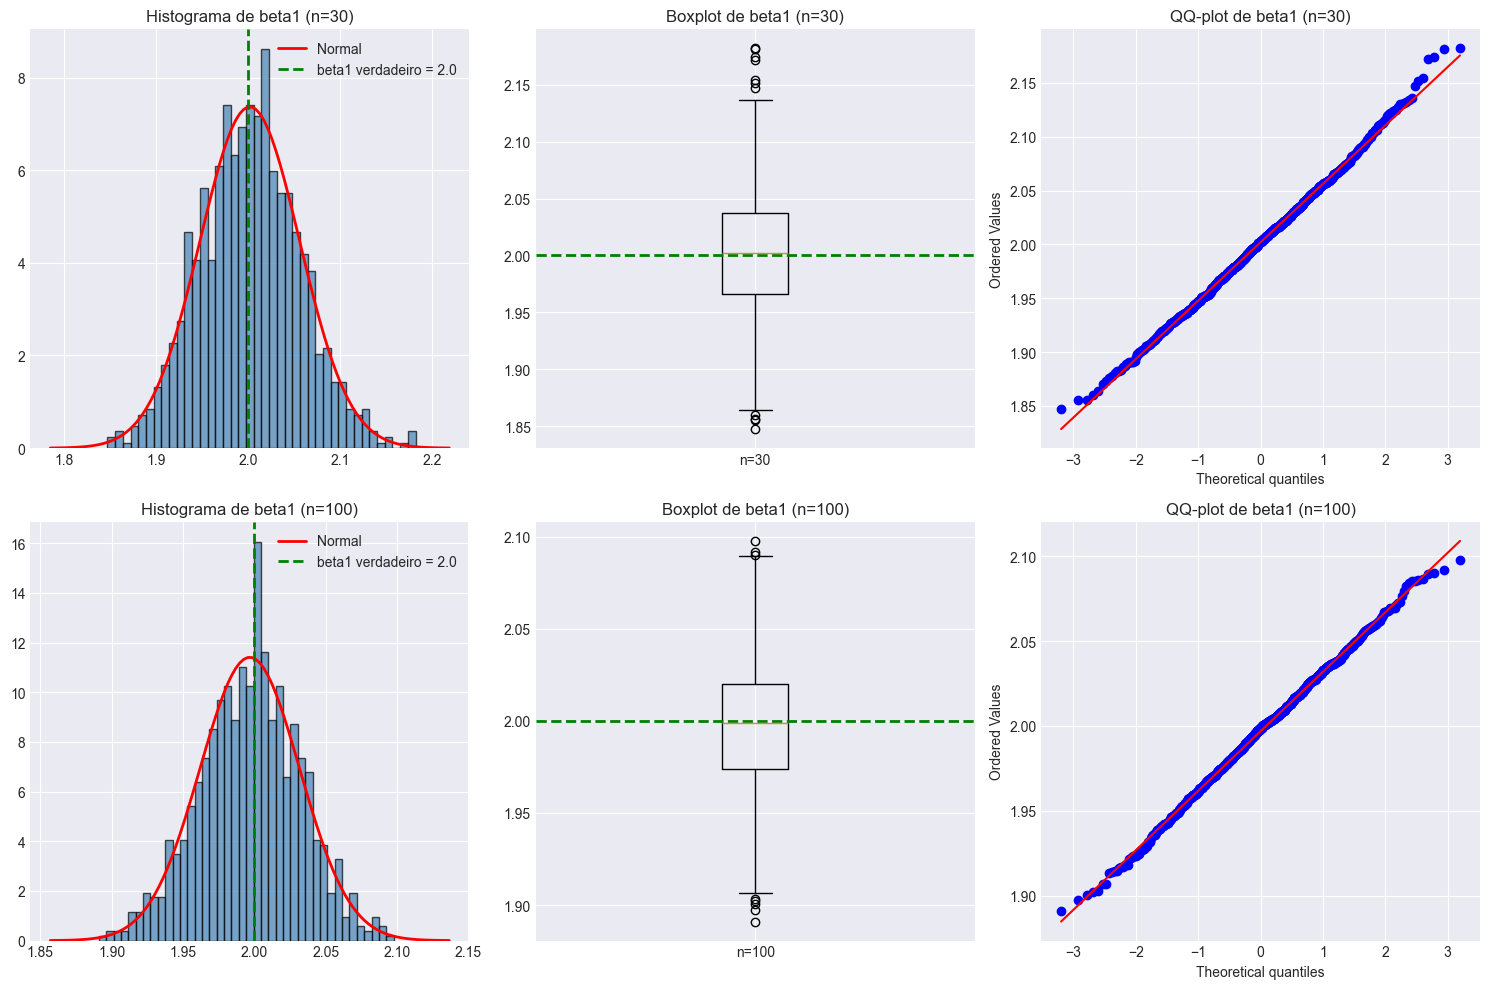

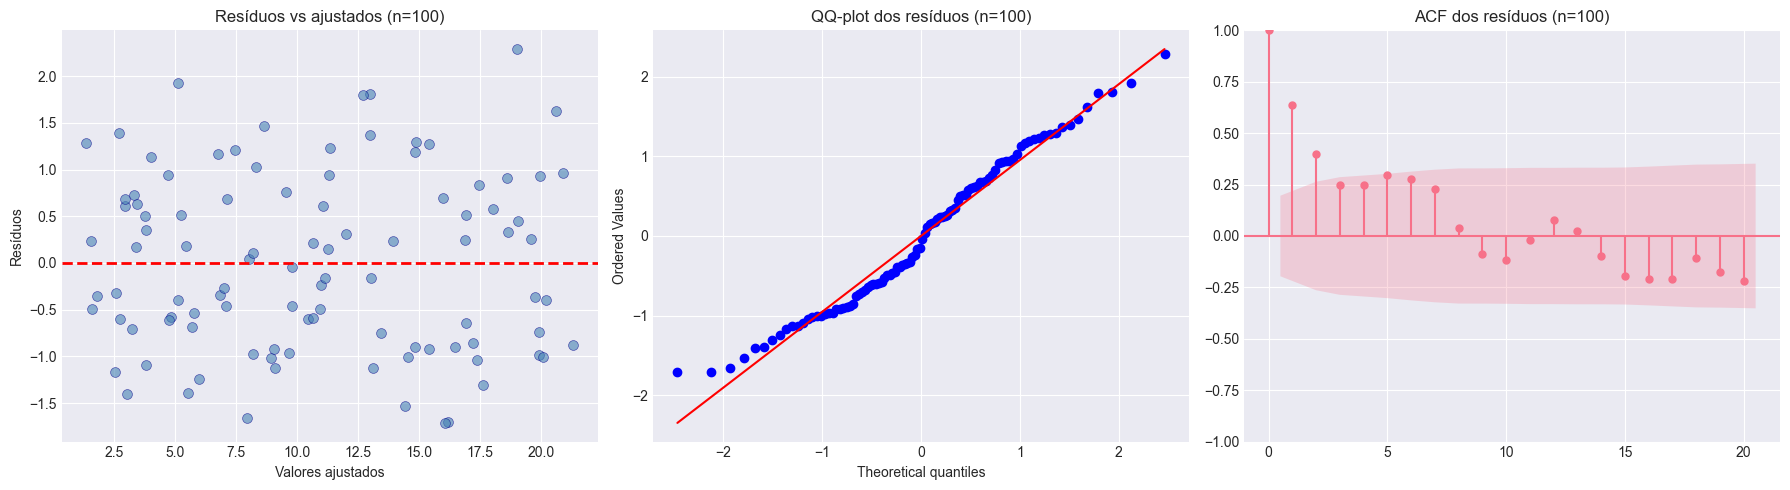


TABELA 4: DIAGNOSTICO DE CORRELACAO SERIAL
  n  DW_medio_alt  DW_medio_H0  DW_referencia
 30      0.836078     0.846285            2.0
100      0.667769     0.671068            2.0

Estatística Durbin-Watson da amostra diagnóstica = 0.707


In [12]:
# 4.1 Visualizações dos estimadores: beta1
fig, axes = plt.subplots(len(SAMPLE_SIZES), 3, figsize=(15, 5 * len(SAMPLE_SIZES)))
if len(SAMPLE_SIZES) == 1:
    axes = axes.reshape(1, -1)
for idx, n in enumerate(SAMPLE_SIZES):
    ax = axes[idx, 0]
    samples = results[n]['beta1_hats']
    ax.hist(samples, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    mu = np.mean(samples)
    sd = np.std(samples)
    grid = np.linspace(mu - 4 * sd, mu + 4 * sd, 100)
    ax.plot(grid, stats.norm.pdf(grid, mu, sd), 'r-', linewidth=2, label='Normal')
    ax.axvline(BETA1_TRUE, color='green', linestyle='--', linewidth=2, label=f'beta1 verdadeiro = {BETA1_TRUE}')
    ax.set_title(f'Histograma de beta1 (n={n})')
    ax.legend()
    ax = axes[idx, 1]
    ax.boxplot([samples], labels=[f'n={n}'], vert=True)
    ax.axhline(BETA1_TRUE, color='green', linestyle='--', linewidth=2)
    ax.set_title(f'Boxplot de beta1 (n={n})')
    ax = axes[idx, 2]
    stats.probplot(samples, dist='norm', plot=ax)
    ax.set_title(f'QQ-plot de beta1 (n={n})')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cenario5_diagnostico_beta1.png'), dpi=100, bbox_inches='tight')
plt.show()

# 4.2 Diagnóstico de resíduos
n_diag = max(SAMPLE_SIZES)
residuals = results[n_diag]['residuals_diagnostic']
fitted = results[n_diag]['fitted_diagnostic']
dw_value = results[n_diag]['dw_diagnostic']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax = axes[0]
ax.scatter(fitted, residuals, alpha=0.6, s=50, color='steelblue', edgecolor='darkblue', linewidth=0.5)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Valores ajustados')
ax.set_ylabel('Resíduos')
ax.set_title(f'Resíduos vs ajustados (n={n_diag})')
ax = axes[1]
stats.probplot(residuals, dist='norm', plot=ax)
ax.set_title(f'QQ-plot dos resíduos (n={n_diag})')
ax = axes[2]
plot_acf(residuals, ax=ax, lags=min(20, len(residuals) - 1), alpha=0.05)
ax.set_title(f'ACF dos resíduos (n={n_diag})')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cenario5_diagnostico_residuos.png'), dpi=100, bbox_inches='tight')
plt.show()

diagnostics_df = pd.DataFrame([{'n': n, 'DW_medio_alt': float(np.mean(results[n]['dw_alt'])), 'DW_medio_H0': float(np.mean(results[n]['dw_null'])), 'DW_referencia': 2.0} for n in SAMPLE_SIZES])
print('\nTABELA 4: DIAGNOSTICO DE CORRELACAO SERIAL')
print(diagnostics_df.to_string(index=False))
print(f'\nEstatística Durbin-Watson da amostra diagnóstica = {dw_value:.3f}')

all_results['diagnostics'] = diagnostics_df

## Resumo e Interpretação Final

1. Estimação: os coeficientes podem permanecer próximos dos valores verdadeiros, mas a variabilidade aumenta quando os erros são correlacionados.
2. Inferência: os intervalos de confiança clássicos tendem a perder precisão porque os erros-padrão ignoram a dependência serial.
3. Testes: o tamanho empírico sob H0 e o poder sob H1 podem ficar distorcidos.
4. Diagnóstico: resíduos ao longo da ordem e ACF ajudam a evidenciar a correlação serial; o DW abaixo de 2 sugere autocorrelação positiva.

Conclusão: o cenário 5 mostra que o MQO pode continuar útil para estimar a média condicional, mas a inferência clássica precisa de cuidados quando a independência dos erros é violada.

In [13]:
# Salvar resultados em CSV
print('\n' + '='*100)
print('SALVANDO RESULTADOS')
print('='*100)
for name, df in all_results.items():
    filepath = os.path.join(OUTPUT_DIR, f'cenario5_{name}.csv')
    df.to_csv(filepath, index=False)
    print(f'✓ Salvo: {filepath}')
print(f'\n✓ Arquivos salvos no diretório: {OUTPUT_DIR}/')
print('='*100)


SALVANDO RESULTADOS
✓ Salvo: cenario5_resultados\cenario5_estimation.csv
✓ Salvo: cenario5_resultados\cenario5_inference.csv
✓ Salvo: cenario5_resultados\cenario5_tests.csv
✓ Salvo: cenario5_resultados\cenario5_diagnostics.csv

✓ Arquivos salvos no diretório: cenario5_resultados/
